# 02 — Exploratory Data Analysis (behavioural)

**Phase 2.** EDA on the **clean** data from `01_cleaning`. We explore real purchasing behaviour
to *justify the modelling choices we designed*:
- **revenue concentration** → is segmentation even worth it? (framing A)
- **one-timer share** → CLV reliability + single-purchase handling (docs 15, 17)
- **spend skew** → justifies `log1p` (doc 09)
- **time & geography** → seasonality; why geography is supporting-only (doc 04)

Loads `data/processed/clean_transactions.parquet` (fast — ~4s vs the ~33s xlsx).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
PHASE = "02_eda"

In [2]:
# Load clean transactions and derive line-level revenue (Quantity x Price).
tx = pd.read_parquet(utils.DATA_PROCESSED / "clean_transactions.parquet")
tx["LineRevenue"] = tx["Quantity"] * tx["Price"]
print(f"clean transactions: {len(tx):,} rows  |  {tx['Customer ID'].nunique():,} customers")
tx.head()

clean transactions: 790,704 rows  |  5,852 customers


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet,LineRevenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,30.00


## 1. Per-customer rollup (exploratory)

A quick customer-level view. (The *real* feature table — with the anchor date etc. — is built
in `03_features`; this is just enough to explore behaviour.)

In [3]:
cust = tx.groupby("Customer ID").agg(
    revenue=("LineRevenue", "sum"),
    invoices=("Invoice", "nunique"),
    items=("Quantity", "sum"),
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max"),
)
print(f"customers: {len(cust):,}")
cust[["revenue", "invoices", "items"]].describe()

customers: 5,852


,revenue,invoices,items
count,"5,852.00","5,852.00","5,852.00"
mean,"2,969.39",6.25,"1,820.94"
std,"14,599.31",12.75,"8,973.46"
min,2.95,1.00,1.00
25%,343.12,1.00,191.00
50%,874.88,3.00,490.00
75%,"2,281.62",7.00,"1,376.00"
max,"608,821.65",373.00,"367,072.00"


## 2. Revenue concentration — is it Pareto? (justifies segmentation)

If a small fraction of customers drives most revenue, treating everyone the same wastes budget.

top 20% of customers drive 77.2% of revenue


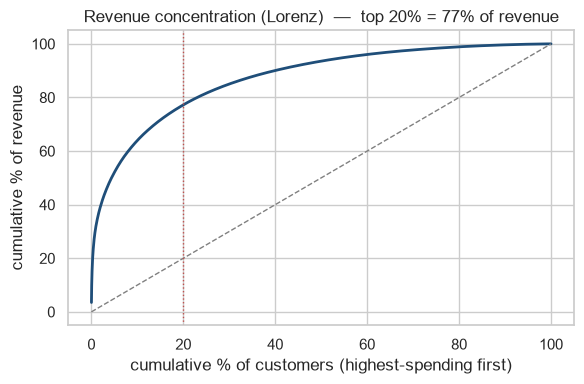

In [4]:
rev_sorted = cust["revenue"].sort_values(ascending=False).to_numpy()
cum_rev = np.cumsum(rev_sorted) / rev_sorted.sum()
cum_cust = np.arange(1, len(rev_sorted) + 1) / len(rev_sorted)
top20 = cum_rev[int(0.20 * len(rev_sorted)) - 1]
print(f"top 20% of customers drive {top20:.1%} of revenue")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cum_cust * 100, cum_rev * 100, color="#1f4e79", lw=2)
ax.plot([0, 100], [0, 100], "--", color="grey", lw=1)        # equality line
ax.axvline(20, color="#c0504d", ls=":", lw=1)
ax.set_xlabel("cumulative % of customers (highest-spending first)")
ax.set_ylabel("cumulative % of revenue")
ax.set_title(f"Revenue concentration (Lorenz)  —  top 20% = {top20:.0%} of revenue")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "revenue_concentration.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Purchase frequency & one-time buyers (CLV reliability)

One-time buyers have BG/NBD `frequency = 0` and are excluded from Gamma-Gamma (docs 15, 17).
Their share is a key driver of how reliable the CLV model will be.

one-time buyers: 1,618  (27.6%)
count   5,852.00
mean        6.25
std        12.75
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       373.00
Name: invoices, dtype: float64


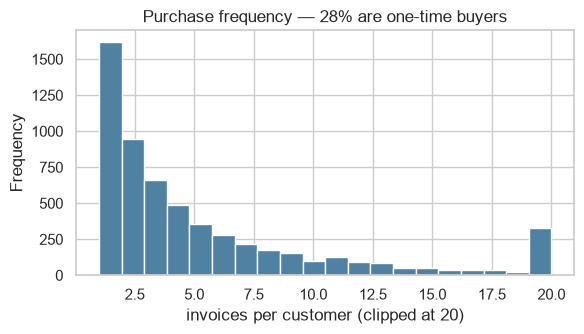

In [5]:
one_timers = int((cust["invoices"] == 1).sum())
print(f"one-time buyers: {one_timers:,}  ({one_timers / len(cust):.1%})")
print(cust["invoices"].describe())

fig, ax = plt.subplots(figsize=(6, 3.5))
cust["invoices"].clip(upper=20).plot.hist(bins=20, ax=ax, color="#4f81a3")
ax.set_xlabel("invoices per customer (clipped at 20)")
ax.set_title(f"Purchase frequency — {one_timers / len(cust):.0%} are one-time buyers")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "frequency_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Spend skew (justifies `log1p` — doc 09)

Customer total spend is heavily right-skewed; `log1p` compresses the tail toward symmetry.

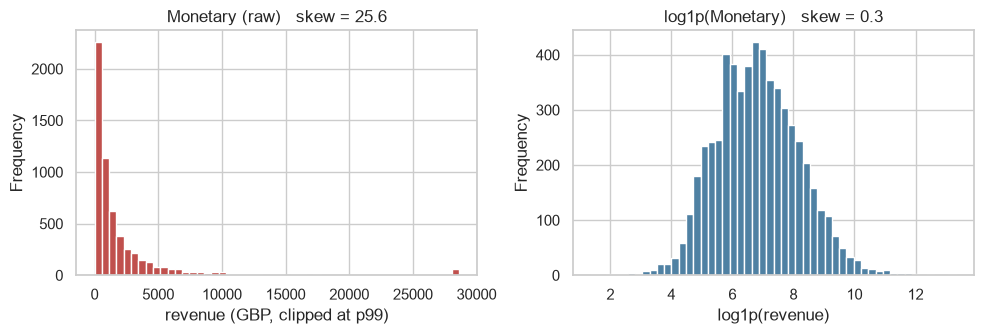

In [6]:
rev = cust["revenue"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
rev.clip(upper=rev.quantile(0.99)).plot.hist(bins=50, ax=axes[0], color="#c0504d")
axes[0].set_title(f"Monetary (raw)   skew = {rev.skew():.1f}")
axes[0].set_xlabel("revenue (GBP, clipped at p99)")
np.log1p(rev).plot.hist(bins=50, ax=axes[1], color="#4f81a3")
axes[1].set_title(f"log1p(Monetary)   skew = {np.log1p(rev).skew():.1f}")
axes[1].set_xlabel("log1p(revenue)")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "spend_skew.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Time patterns (seasonality)

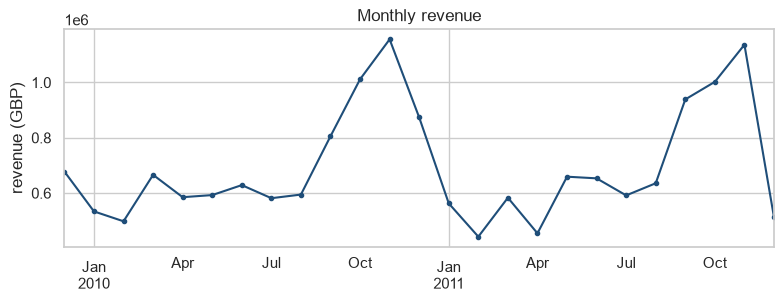

In [7]:
monthly = tx.set_index("InvoiceDate").resample("ME")["LineRevenue"].sum()
fig, ax = plt.subplots(figsize=(8, 3.2))
monthly.plot(ax=ax, color="#1f4e79", marker="o", ms=3)
ax.set_title("Monthly revenue")
ax.set_ylabel("revenue (GBP)")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "monthly_revenue.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Geography (UK dominance — why geography is supporting-only, doc 04)

UK share of revenue: 83.8%   |   countries: 41


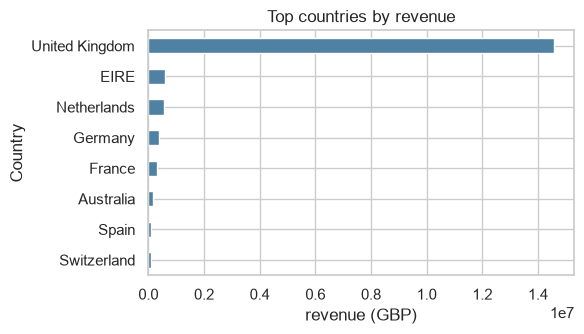

In [8]:
by_country = tx.groupby("Country")["LineRevenue"].sum().sort_values(ascending=False)
uk_share = by_country.get("United Kingdom", 0) / by_country.sum()
print(f"UK share of revenue: {uk_share:.1%}   |   countries: {tx['Country'].nunique()}")

fig, ax = plt.subplots(figsize=(6, 3.5))
by_country.head(8).iloc[::-1].plot.barh(ax=ax, color="#4f81a3")
ax.set_title("Top countries by revenue")
ax.set_xlabel("revenue (GBP)")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "geography.png"), dpi=150, bbox_inches="tight")
plt.show()

---
**What we learned (informs `03_features`):**
- revenue is concentrated → segmentation is worth doing (framing A)
- a large share are one-time buyers → CLV-reliability caveat + single-purchase handling (doc 17)
- spend is heavily right-skewed → `log1p` is justified (doc 09)
- strong seasonality; UK-dominated → geography stays supporting-only (doc 04)